In [7]:
# ===============================
# WATER QUALITY CLASSIFICATION PROJECT
# ML VERSION
# ===============================

# 1. IMPORT LIBRARIES(for the model comparison is made between Logistic Regression and Random Forest Classifier)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. LOAD DATA( the dataset belongs to the PRIN project conducted during the years 2024 and 2025 across 10 ponds in the Castel Porziano region, and is already cleaned )

df = pd.read_csv(r"C:\Users\divya\Downloads\chemical_parameters.csv")

print("Initial Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())



Initial Shape: (998, 26)

Columns:
 Index(['locality', 'eventDate', 'decimalLatitude', 'decimalLongitude',
       'nitrates', 'phosphates', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25'],
      dtype='object')

First 5 rows:
   locality   eventDate  decimalLatitude  decimalLongitude  nitrates  \
0   Anatre  2024-04-23         41.77479          12.42026     0.030   
1   Anatre  2024-04-23         41.77479          12.42026     0.770   
2   Anatre  2024-05-07         41.77479          12.42026     0.000   
3   Anatre  2024-05-07         41.77479          12.42026     0.000   
4   Anatre  2024-07-11         41.77464          12.41996     0.013   

   phosphates  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  

In [8]:
# 3. KEEP ONLY REQUIRED COLUMNS ( our dependent variables are the chemical parameters)

df = df[["nitrates", "phosphates"]].copy()

# 4. CLEAN DATA (null values are removed and normalised to numeric type)
df["nitrates"] = pd.to_numeric(df["nitrates"], errors="coerce")
df["phosphates"] = pd.to_numeric(df["phosphates"], errors="coerce")

df = df.dropna()

print("\nAfter Cleaning Shape:", df.shape)
print("\nSummary:\n", df.describe())




After Cleaning Shape: (45, 2)

Summary:
         nitrates  phosphates
count  45.000000   45.000000
mean    0.309400    0.050238
std     0.817242    0.074262
min     0.000000    0.000000
25%     0.000000    0.005000
50%     0.000000    0.028000
75%     0.080000    0.052000
max     4.540000    0.347000


In [13]:
# 5. CREATE TARGET VARIABLE
df["pollution"] = (df["nitrates"] > 0.5).astype(int)

print("\nClass Distribution:\n", df["pollution"].value_counts())
print("\nClass Distribution (percentage):\n", df["pollution"].value_counts(normalize=True))

# 6. DEFINE FEATURES AND TARGET 
X = df[["nitrates", "phosphates"]]
y = df["pollution"]

# 7. TRAIN-TEST SPLIT (here, 80:20 is used for the splitting)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. SCALE FEATURES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Class Distribution:
 pollution
0    37
1     8
Name: count, dtype: int64

Class Distribution (percentage):
 pollution
0    0.822222
1    0.177778
Name: proportion, dtype: float64


In [14]:

# ===============================
# 9. LOGISTIC REGRESSION MODEL (First model chosen because as we are assessing the cause and effect relationship binary classification and matches the problem type) 
# ===============================
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# ===============================
# 10. RANDOM FOREST MODEL (as this model handles the non-linearity)
# ===============================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



LOGISTIC REGRESSION RESULTS
Accuracy: 0.7777777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       0.00      0.00      0.00         2

    accuracy                           0.78         9
   macro avg       0.39      0.50      0.44         9
weighted avg       0.60      0.78      0.68         9


Confusion Matrix:
 [[7 0]
 [2 0]]

RANDOM FOREST RESULTS
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         2

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Confusion Matrix:
 [[7 0]
 [0 2]]


C:\Users\divya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:

# ===============================
# 11. MODEL COMPARISON
# ===============================
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)



FINAL MODEL COMPARISON
Logistic Regression Accuracy: 0.7777777777777778
Random Forest Accuracy: 1.0


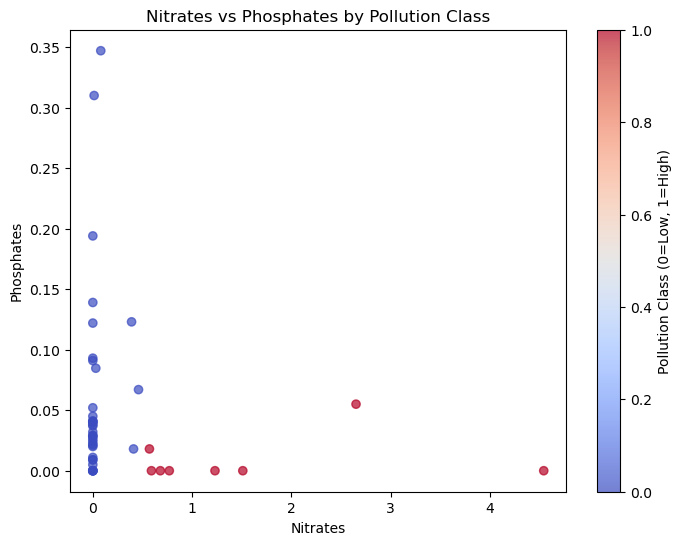

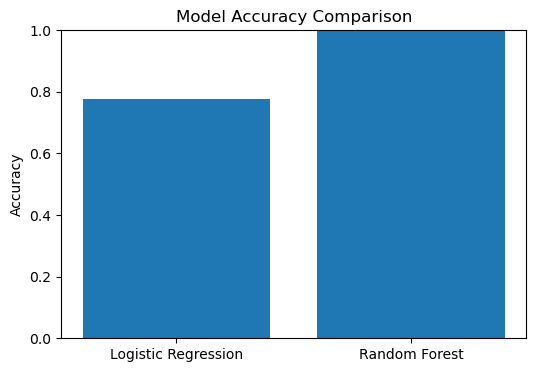

In [20]:

# ===============================
# 12. SIMPLE VISUALIZATION
# ===============================

# Scatter plot of nitrates vs phosphates colored by pollution class
plt.figure(figsize=(8, 6))
plt.scatter(df["nitrates"], df["phosphates"], c=df["pollution"], cmap="coolwarm", alpha=0.7)
plt.xlabel("Nitrates")
plt.ylabel("Phosphates")
plt.title("Nitrates vs Phosphates by Pollution Class")
plt.colorbar(label="Pollution Class (0=Low, 1=High)")
plt.savefig("scatter_plot.png")
plt.show()

# Bar chart for model comparison
plt.figure(figsize=(6, 4))
plt.bar(["Logistic Regression", "Random Forest"], [lr_acc, rf_acc])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.savefig("model_accuracy_plot.png")
plt.show()

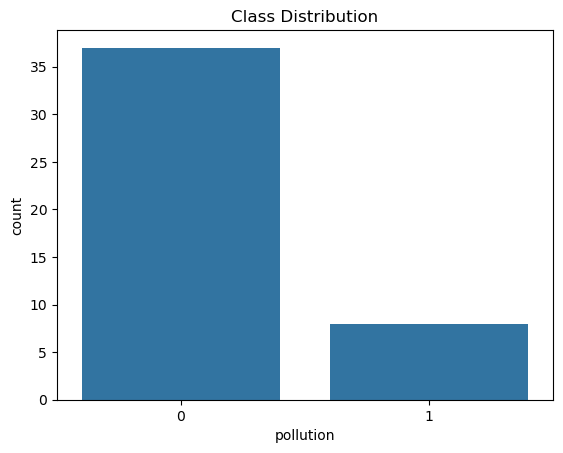

In [19]:
import seaborn as sns

sns.countplot(x=df["pollution"])
plt.title("Class Distribution")
plt.savefig("classdistribution_plot.png")
plt.show()